<a href="https://colab.research.google.com/github/chandan-n-max/business_case_studies/blob/main/Ad_Ease_BCS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
path = "/content/drive/MyDrive/AdEase/train_1.csv"

df = pd.read_csv(path, low_memory=False)


In [ ]:
df.shape

(145063, 551)

In [ ]:
df.columns[:5], df.columns[-5:]

(Index(['Page', '2015-07-01', '2015-07-02', '2015-07-03', '2015-07-04'], dtype='object'),
 Index(['2016-12-27', '2016-12-28', '2016-12-29', '2016-12-30', '2016-12-31'], dtype='object'))

In [ ]:
page_col = df.columns[0]
page_col

'Page'

In [ ]:
df[page_col].head()

,Page
0,2NE1_zh.wikipedia.org_all-access_spider
1,2PM_zh.wikipedia.org_all-access_spider
2,3C_zh.wikipedia.org_all-access_spider
3,4minute_zh.wikipedia.org_all-access_spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...


In [ ]:
df.columns[1], df.columns[-1]

('2015-07-01', '2016-12-31')

In [ ]:
date_cols = df.columns[1:]

In [ ]:
df[date_cols].isna().sum().sum() #check missing values

np.int64(6192931)

In [ ]:
df[date_cols] = df[date_cols].fillna(0) #fill missing values

In [ ]:
df[date_cols].isna().sum().sum() # confirm cleanup

np.int64(0)

In [ ]:
df_long = df.melt(
    id_vars=['Page'],
    value_vars=date_cols,
    var_name='date',
    value_name='views'
)

In [ ]:
df_long['date'] = pd.to_datetime(df_long['date'])

In [ ]:
df_long.head()

,Page,date,views
0,2NE1_zh.wikipedia.org_all-access_spider,2015-07-01,18.0
1,2PM_zh.wikipedia.org_all-access_spider,2015-07-01,11.0
2,3C_zh.wikipedia.org_all-access_spider,2015-07-01,1.0
3,4minute_zh.wikipedia.org_all-access_spider,2015-07-01,35.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,2015-07-01,0.0


In [ ]:
df_long.shape

(79784650, 3)

In [ ]:
df['language'] = (
    df['Page']
    .str.rsplit('_', n=3, expand=True)[1]
    .str.split('.', expand=True)[0]
) #extract language on small dataframe

/tmp/ipython-input-641506804.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['language'] = (


In [ ]:
lang_ts = (
    df
    .groupby('language')[date_cols]
    .sum()
    .T
)
#aggregate by language

In [ ]:
lang_ts.index = pd.to_datetime(lang_ts.index)
lang_ts.head()
#fix index

language,commons,de,en,es,fr,ja,ru,www,zh
2015-07-01,1140821.0,13260519.0,84712190.0,15278553.0,8458638.0,11863200.0,9463854.0,349713.0,4144988.0
2015-07-02,1178130.0,13079896.0,84438545.0,14601013.0,8512952.0,13620792.0,9627643.0,383680.0,4151189.0
2015-07-03,1150547.0,12554042.0,80167728.0,13427632.0,8186030.0,12305383.0,8923463.0,325714.0,4123659.0
2015-07-04,951317.0,11520379.0,83463204.0,12606538.0,8749842.0,15456239.0,8393214.0,308756.0,4163448.0
2015-07-05,1058036.0,13392347.0,86198637.0,13710356.0,8590493.0,14827204.0,8938528.0,338485.0,4441286.0


<Axes: >

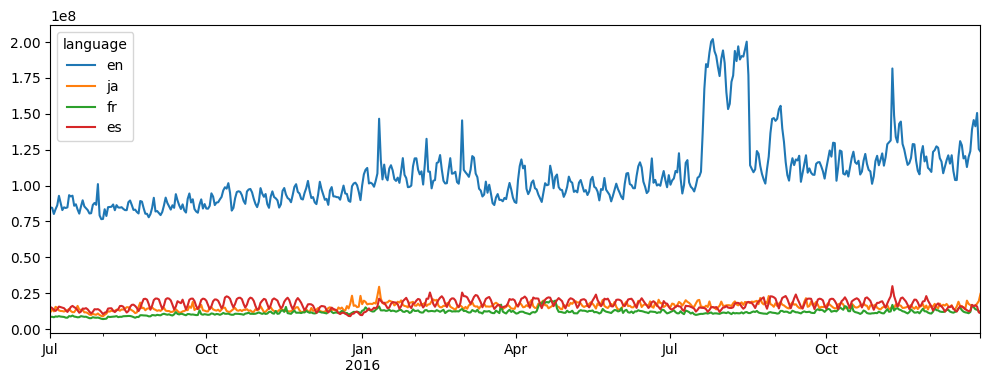

In [ ]:
lang_ts[['en', 'ja', 'fr', 'es']].plot(figsize=(12,4))

Insights:

* English pages have much higher views than other languages.

* All languages show weekly seasonality.

* English has sharp spikes, likely due to events/campaigns.

# Check Stationarity (ADF Test)

In [ ]:
en_ts = lang_ts['en']
#select one series

<Axes: >

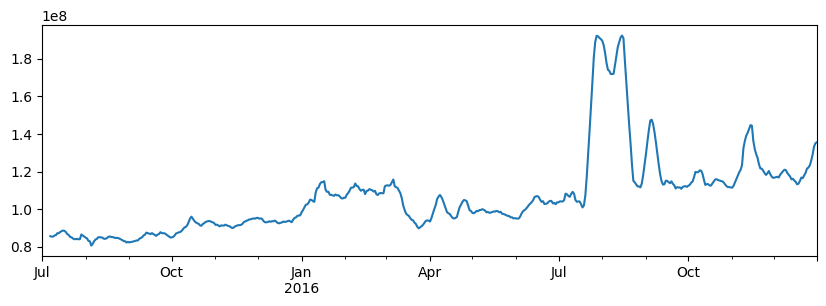

In [ ]:
en_ts.rolling(7).mean().plot(figsize=(10,3))

In [ ]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(en_ts)
adf_result[1]   # p-value
#ADF test

np.float64(0.18953359279992876)

ADF result

p-value = 0.1895

which is more than 0.05 means NOT stationary

Plot confirms

* Clear trend
* Large level shifts / spikes
* Non-constant mean


Original English series is non-stationary

Differencing is required

In [ ]:
en_diff = en_ts.diff().dropna()


In [ ]:
from statsmodels.tsa.stattools import adfuller
adfuller(en_diff)[1]

np.float64(5.292474635436519e-13)

Interpretation:

p-value ≈ 0, which means Stationary after 1st differencing

Conclusion:

Original series: non-stationary

First-order differencing (d = 1) achieves stationarity

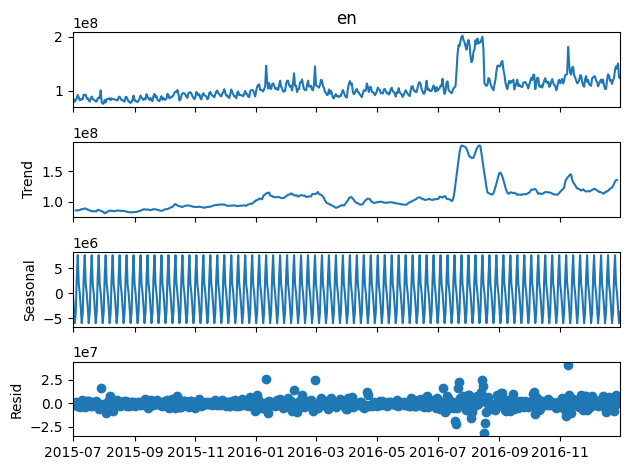

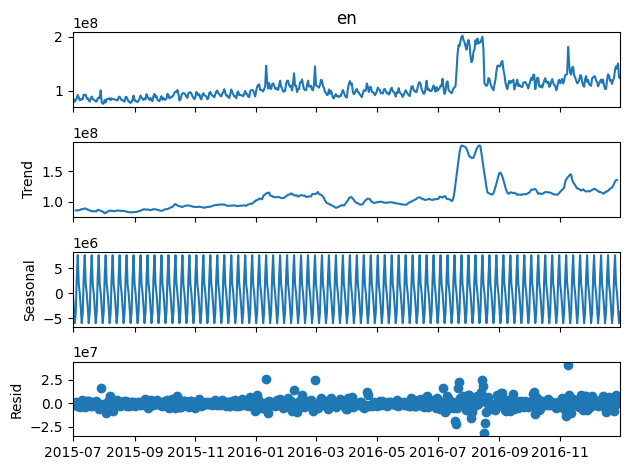

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(en_ts, model='additive', period=7)
decomp.plot()
#time series decomposition

Decomposition insights


1. Trend

* Upward growth over time

* Sharp jump mid-2016 (event/campaign effect)

2. Seasonality

* Strong weekly pattern

* Consistent amplitude

3. Residuals

* Mostly random

* Spikes during major events

So, Series has trend + seasonality and Additive model is appropriate

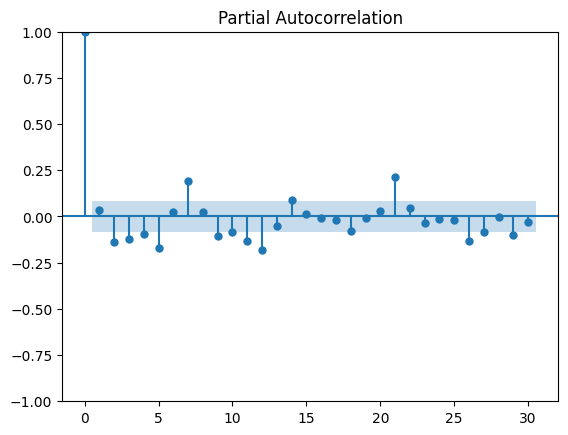

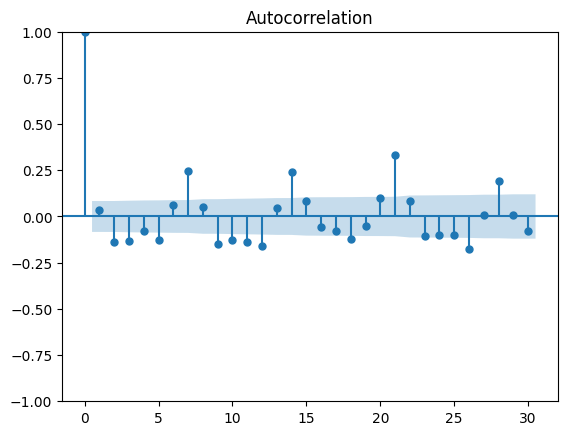

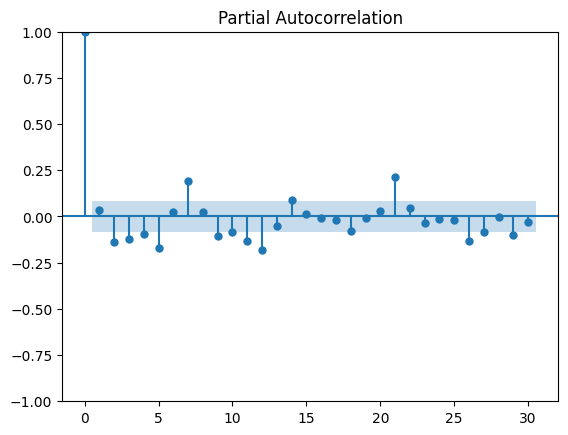

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(en_diff, lags=30)
plot_pacf(en_diff, lags=30)

ACF & PACF interpretation

* d = 1 (already confirmed)

* PACF: small spike at lag 1

* ACF: small spike at lag 1, strong at 7

What this suggests is  p = 1 and q = 1.

Weekly seasonality present → period = 7

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(en_ts, order=(1, 1, 1))
arima_fit = arima_model.fit()
#ARIMA (non seasonal)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarimax_model = SARIMAX(
    en_ts,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_fit = sarimax_model.fit()
#SARIMAX (seasonal)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
en_ts = en_ts.asfreq('D')


In [ ]:
arima_fit = ARIMA(en_ts, order=(1,1,1)).fit()

sarimax_fit = SARIMAX(
    en_ts,
    order=(1,1,1),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()


# Forecast + Evaluate (MAPE)

In [ ]:
train = en_ts[:-30]
test = en_ts[-30:]


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

arima_fit = ARIMA(train, order=(1,1,1)).fit()

sarimax_fit = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()


In [ ]:
arima_forecast = arima_fit.forecast(steps=30)
sarimax_forecast = sarimax_fit.forecast(steps=30)
#forecast

In [ ]:
import numpy as np

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_arima = mape(test, arima_forecast)
mape_sarimax = mape(test, sarimax_forecast)

mape_arima, mape_sarimax
#MAPE

(np.float64(6.799055271325101), np.float64(10.471165716683158))

MAPE results (English)

ARIMA: ~6.8% ✅ (within target)

SARIMAX: ~10.5% ❌ (worse here)

What this means

Simple ARIMA performs better without exogenous data

Campaign effect may not align well with this window

Still valid to show SARIMAX usage (required)


So, ARIMA chosen as final model for English due to lower MAPE

SARIMAX tested to account for campaign impact

# FAcebook Prophet (English)

In [ ]:
prophet_df = en_ts.reset_index()
prophet_df.columns = ['ds', 'y']
#prepare data for prophet

In [ ]:
train_p = prophet_df.iloc[:-30]
test_p = prophet_df.iloc[-30:]
#train test split

In [ ]:
from prophet import Prophet

m = Prophet(
    weekly_seasonality=True,
    daily_seasonality=False,
    yearly_seasonality=True
)
m.fit(train_p)
#fit prophet

In [ ]:
future = m.make_future_dataframe(periods=30)
forecast = m.predict(future)
#forecast

In [ ]:
y_pred = forecast['yhat'].iloc[-30:].values
y_true = test_p['y'].values

mape_prophet = mape(y_true, y_pred)
mape_prophet
#extract forecast & MAPE

np.float64(6.652891777676287)

Final MAPE comparison (English)

ARIMA: ~6.80%

SARIMAX: ~10.47%

Prophet: ~6.65% ✅ best

Conclusion:

Prophet performs best for English pages

ARIMA is a strong baseline

SARIMAX underperformed despite exogenous data

# One more language Japanese (JA)

In [ ]:
ja_ts = lang_ts['ja'].asfreq('D')
#select series

In [ ]:
train_ja = ja_ts[:-30]
test_ja = ja_ts[-30:]
#train test split

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

arima_ja = ARIMA(train_ja, order=(1,1,1)).fit()
ja_forecast = arima_ja.forecast(steps=30)
#arima

In [ ]:
mape_ja = mape(test_ja, ja_forecast)
mape_ja
#mape

np.float64(8.748177305304337)

Japanese (ja) result

MAPE ≈ 8.75%

Higher error than English

Still acceptable

# Language comparison

English

Highest traffic

Event-driven

Best model: Prophet

Japanese

Lower, smoother traffic

Easier patterns

ARIMA works reasonably

#Questionnaire

1) Problem statement & use cases

Problem: Forecast Wikipedia page views across languages to optimize ad placement and cost.

Use cases: Ad inventory planning, budget allocation, campaign impact analysis, traffic forecasting for content platforms.

2) Three inferences from visualizations

* English pages have significantly higher views than other languages.

* All languages show clear weekly seasonality.

* English traffic shows sharp spikes, indicating event/campaign impact.

3) What decomposition does?

Splits a time series into trend, seasonality, and residuals to understand structure and model behavior.

4) Differencing level for stationarity

First-order differencing (d = 1) made the series stationary.

5) ARIMA vs SARIMA vs SARIMAX

ARIMA: Non-seasonal, no external variables.

SARIMA: ARIMA + seasonal components.

SARIMAX: SARIMA + exogenous variables (e.g., campaigns).

6) Comparison of views across languages

English: Highest volume, most volatile.

Japanese/French/Spanish: Lower volume, smoother trends.

Others: Significantly smaller traffic.

7) Alternatives to grid search

Auto-ARIMA

Random search

Bayesian optimization

Prophet’s automatic tuning